In [1]:
import numpy as np
from pathlib import Path
from skimage import io
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
from skimage.color import rgb2hsv
from skimage.morphology import binary_opening, binary_closing, disk, remove_small_objects, remove_small_holes
from scipy.ndimage import maximum_filter, minimum_filter, uniform_filter, sobel
from skimage.filters import frangi

In [2]:
# Fijamos la semilla para poder reproducir los resultados
import random
seed = 123
np.random.seed(seed)
random.seed(seed)

In [3]:
# Ruta al dataset
# Lo tenemos en la misma carpeta que el notebook
dataset_path = Path("roads")
sat_path = dataset_path / "sat" # Carpeta con las imagenes por satelite
gt_path = dataset_path / "gt" # Carpeta con las carreteras marcadas

# Cargar las imágenes
# Las ordenamos para que cada que cada imagen de la carpeta sat este en la misma posicion que en la carpeta gt (tienen el mismo nombre)
sat_files = sorted(sat_path.glob("*.tif*")) # Leer todas las de la carpeta a la vez
gt_files = sorted(gt_path.glob("*.tif*"))

# Leer imágenes y máscaras
images = []
masks = []

for sat_file, gt_file in zip(sat_files, gt_files):
    # Cargar imagen del satelite
    img = io.imread(sat_file)
    images.append(img)
    
    # Cargar máscara y binarizar
    mask = io.imread(gt_file)
    mask = (mask > 128).astype(np.uint8) # Lo tenemos que poner en 0 y 1 porque ahora tiene como valores 0 y 255
    masks.append(mask)

images = np.array(images)
masks = np.array(masks)

print(f"Shape imágenes: {images.shape}")
print(f"Shape máscaras: {masks.shape}")

Shape imágenes: (20, 1500, 1500, 3)
Shape máscaras: (20, 1500, 1500)


In [4]:
# Dividir aleatoriamente
n_total = len(images)
indices = np.random.permutation(n_total) # Devuelve una secuencia desordenada de numeros del 0 a n_total - 1

# Dividir indices
test_indices = indices[:2] # 2 primeras para test
val_indices = indices[2:4] # 2 siguientes para val
train_indices = indices[4:] # resto para train

X_test = images[test_indices]
y_test = masks[test_indices]

X_val = images[val_indices]
y_val = masks[val_indices]

X_train = images[train_indices]
y_train = masks[train_indices]

print(f"Train: {len(X_train)} imágenes")
print(f"Validación: {len(X_val)} imágenes")
print(f"Test: {len(X_test)} imágenes")

Train: 16 imágenes
Validación: 2 imágenes
Test: 2 imágenes


PREPROCESADO

In [5]:
def normalize_images(images):
    """Normaliza imágenes al rango [0, 1]"""
    return images.astype(np.float32) / 255.0

In [6]:
def flatten_data(X, y):
    """Aplana los datos"""
    X_flat = X.reshape(-1, X.shape[-1])
    y_flat = y.reshape(-1)
    return X_flat, y_flat

"""
Convierte una imagen con varios canales en una lista de píxeles para poder clasificarlos uno por uno. El número de canales sigue igual
Por ejemplo:
Entrada: Forma (10, 10, 3) - una matriz con alto, ancho y 3 canales de color
Salida (X_flat): Forma (100, 3) - una lista de 100 filas, cada una con los 3 valores RGB de un píxel
Muchos clasificadores (como SVM o Random Forest) esperan recibir datos en formato de tabla, donde cada fila es un ejemplo.
"""

'\nConvierte una imagen con varios canales en una lista de píxeles para poder clasificarlos uno por uno. El número de canales sigue igual\nPor ejemplo:\nEntrada: Forma (10, 10, 3) - una matriz con alto, ancho y 3 canales de color\nSalida (X_flat): Forma (100, 3) - una lista de 100 filas, cada una con los 3 valores RGB de un píxel\nMuchos clasificadores (como SVM o Random Forest) esperan recibir datos en formato de tabla, donde cada fila es un ejemplo.\n'

In [7]:
def undersample(image, mask):
    """Balancea datos para tener igual cantidad de cada clase"""
    # Índices de cada clase
    road_idx = np.where(mask == 1)[0]
    bg_idx = np.where(mask == 0)[0]
    
    # Mantener todos los píxeles de carretera
    # Reducir fondo al mismo número
    n_road = len(road_idx)
    bg_sampled = np.random.choice(bg_idx, n_road, replace=False)
    
    # Combinar y mezclar
    selected = np.concatenate([road_idx, bg_sampled])
    np.random.shuffle(selected)
    
    return image[selected], mask[selected]

# NOTA: AL HACER EL UNDERSAMPLING NOS QUEDAMOS SOLO CON ALGUNAS MUESTRAS ASI QUE PERDEMOS QUE PIXELES ESTAN AL LADO DE OTROS
# tenemos que extraer las características antes de hacer el undersampling (con vecindad) cuando vayamos a hacerlo

In [8]:
# PROBAR SOLO CON RGB

#  Normalizar todos los conjuntos
X_train_norm = normalize_images(X_train)
X_val_norm = normalize_images(X_val)
X_test_norm = normalize_images(X_test)

print(f"Rango sin normalizar train: {X_train.min():.2f}-{X_train.max():.2f}")
print(f"Rango normalizado train: {X_train_norm.min():.2f}-{X_train_norm.max():.2f}")

# Aplanar todos los conjuntos
X_train_flat, y_train_flat = flatten_data(X_train_norm, y_train)
X_val_flat, y_val_flat = flatten_data(X_val_norm, y_val)
X_test_flat, y_test_flat = flatten_data(X_test_norm, y_test)

print(f"\nDatos aplanados (inputs ; target):")
print(f"  Train: {X_train_flat.shape} ; {y_train_flat.shape}")
print(f"  Val:   {X_val_flat.shape} ; {y_val_flat.shape}")
print(f"  Test:  {X_test_flat.shape} ; {y_test_flat.shape}")

# Aplicar undersampling solo a train
X_train_balanced, y_train_balanced = undersample(X_train_flat, y_train_flat)

print(f"\nDatos después de undersampling (inputs ; target):")
print(f"  Train: {X_train_balanced.shape} ; {y_train_balanced.shape}")

print(f"\nDatos preparados finales (inputs ; target):")
print(f"  Train: {X_train_balanced.shape} → {y_train_balanced.shape}")
print(f"  Val:   {X_val_flat.shape} ; {y_val_flat.shape}")
print(f"  Test:  {X_test_flat.shape} ; {y_test_flat.shape}")

Rango sin normalizar train: 0.00-255.00
Rango normalizado train: 0.00-1.00

Datos aplanados (inputs ; target):
  Train: (36000000, 3) ; (36000000,)
  Val:   (4500000, 3) ; (4500000,)
  Test:  (4500000, 3) ; (4500000,)

Datos después de undersampling (inputs ; target):
  Train: (2529114, 3) ; (2529114,)

Datos preparados finales (inputs ; target):
  Train: (2529114, 3) → (2529114,)
  Val:   (4500000, 3) ; (4500000,)
  Test:  (4500000, 3) ; (4500000,)



=== ENTRENAMIENTO ===
Entrenando con 2529114 píxeles balanceados...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   18.1s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   46.4s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.


Modelo entrenado

=== EVALUACIÓN ===


[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    7.6s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:   18.1s finished


Validación:
  Accuracy:  0.8197
  Precision: 0.2267
  Recall:    0.7816
  F1-Score:  0.3514


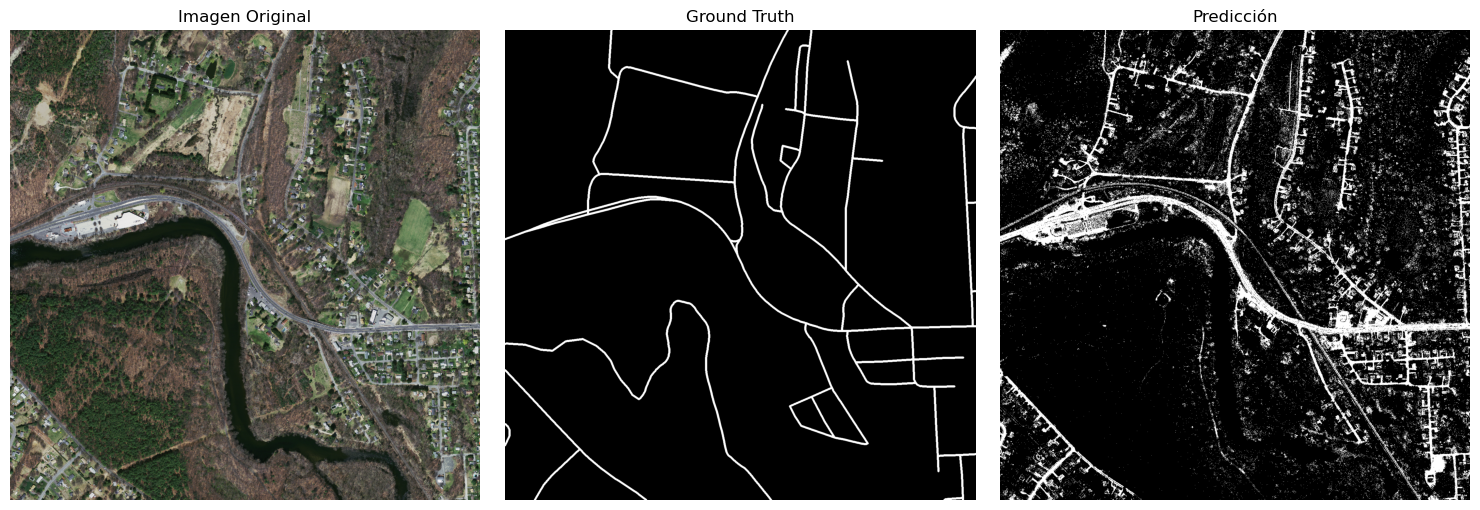

In [12]:
print("\n=== ENTRENAMIENTO ===")

print(f"Entrenando con {len(X_train_balanced)} píxeles balanceados...")

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=seed,
    n_jobs=-1,
    verbose=1
)# PARECE QUE A RANDOM FOREST NO LE PUEDES PASAR VALIDATION ??????

model.fit(X_train_balanced, y_train_balanced)

print("Modelo entrenado")

print("\n=== EVALUACIÓN ===")

# EN REALIDAD ESTO HABRIA QUE HACERLO CON TEST PERO AUN NO ME PUSE A HACER ESTO LMAO
# Evaluar en validación
y_val_pred = model.predict(X_val_flat)

acc = accuracy_score(y_val_flat, y_val_pred)
prec = precision_score(y_val_flat, y_val_pred)
rec = recall_score(y_val_flat, y_val_pred)
f1 = f1_score(y_val_flat, y_val_pred)

print(f"Validación:")
print(f"  Accuracy:  {acc:.4f}")
print(f"  Precision: {prec:.4f}")
print(f"  Recall:    {rec:.4f}")
print(f"  F1-Score:  {f1:.4f}")

# Visualizar predicción en una imagen de validación
y_val_pred_img = y_val_pred.reshape(X_val.shape[0], X_val.shape[1], X_val.shape[2])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(X_val[0])
axes[0].set_title("Imagen Original")
axes[0].axis('off')

axes[1].imshow(y_val[0], cmap='gray')
axes[1].set_title("Ground Truth")
axes[1].axis('off')

axes[2].imshow(y_val_pred_img[0], cmap='gray')
axes[2].set_title("Predicción")
axes[2].axis('off')

plt.tight_layout()
plt.show()

PREGUNTA: LA EXTRACCIÓN DE CARACTERÍSTICAS SE HACE EN LOS 3 (TRAIN, TEST Y VALIDATION) O SOLO EN TRAIN?

In [10]:
def extract_hsv_features(img_norm):
    """Extrae características HSV"""
    hsv = rgb2hsv(img_norm)
    features = []
    features.append(hsv[:,:,0])
    features.append(hsv[:,:,1])
    features.append(hsv[:,:,2])
    return features

In [11]:
def extract_local_mean(image, window_size=7):
    """Textura uniforme de carreteras"""    
    features = []
    
    for channel in range(image.shape[2]):
        media = uniform_filter(image[:, :, channel], size=window_size)
        features.append(media)
    
    return features

In [ ]:
def extract_line_detection_features(image):
    """LA MÁS IMPORTANTE para carreteras finas"""
    
    features = []
    
    gray = np.mean(image, axis=2) # la ponemos en escala de gris
    
    sigmas_fine = [1, 2, 3]  # Escalas pequeñas
    
    # Frangi es el mejor para líneas
    frangi_light = frangi(gray, sigmas=sigmas_fine, black_ridges=False)
    features.append(frangi_light)
    
    frangi_dark = frangi(gray, sigmas=sigmas_fine, black_ridges=True)
    features.append(frangi_dark)
    
    return features

In [ ]:
def extract_gradient_features(image):
    """Bordes de carreteras"""
    from scipy.ndimage import sobel
    
    features = []
    
    gray = np.mean(image, axis=2)
    
    gx = sobel(gray, axis=1)
    gy = sobel(gray, axis=0)
    
    magnitud = np.sqrt(gx**2 + gy**2)
    features.append(magnitud)
    
    return features

In [ ]:
def extract_intensities(image):
    features = []

    intensity = np.mean(image, axis=2)
    # feature_maps.append(intensity)

    # Máximo local (resalta píxeles brillantes)
    max_intensity = maximum_filter(intensity, size=7)
    features.append(max_intensity)
        
    # Mínimo local (resalta píxeles oscuros)
    min_intensity = minimum_filter(intensity, size=7)
    features.append(min_intensity)

    return features

In [ ]:
def extract_morphological_features(image):
    """
    Detecta estructuras lineales claras/oscuras
    Reduce falsos positivos en texturas irregulares
    """
    from skimage.morphology import white_tophat, rectangle # importo las cosas dentro porque solo eran pruebas
    
    features = []
    gray = np.mean(image, axis=2)
    gray_uint = (gray * 255).astype(np.uint8)
    
    # Top-hat para líneas verticales
    selem_v = rectangle(5, 1)
    tophat_v = white_tophat(gray_uint, selem_v)
    features.append(tophat_v.astype(float) / 255.0)
    
    # Top-hat para líneas horizontales
    selem_h = rectangle(1, 5)
    tophat_h = white_tophat(gray_uint, selem_h)
    features.append(tophat_h.astype(float) / 255.0)
    
    return features

In [ ]:
def extract_features(image): # LA IMAGEN TIENE QUE ESTAR NORMALIZADA
    features = []

    for c in range(3): # AÑADIR CADA CANAL RGB
        features.append(image[:, :, c])

    hsv = extract_hsv_features(image)
    features.extend(hsv) # Añadir cada matriz (se puede usar extend porque la funcion las devuelve dentro de una lista)
    
    media_local = extract_local_mean(image)
    features.extend(media_local)

    line_detection = extract_line_detection_features(image)
    features.extend(line_detection)

    gradient_features = extract_gradient_features(image)
    features.extend(gradient_features)

    intensity_features = extract_intensities(image)
    features.extend(intensity_features)

    return np.dstack(features) # Se usa stack para pasar la lista a matriz

In [ ]:
def extract_features_dataset(extract_features_function, images):
    """Extrae características para todas las imágenes
    Le pasamos la función para que sea más general""" 
    all_features = []
    for img in images:   
        features = extract_features_function(img)
        all_features.append(features)
    return np.array(all_features)

In [ ]:
# Normalizar todos los conjuntos
X_train_norm = normalize_images(X_train)
X_val_norm = normalize_images(X_val)
X_test_norm = normalize_images(X_test)

print(f"Rango sin normalizar: {X_train.min():.2f}-{X_train.max():.2f}")
print(f"Rango normalizado: {X_train_norm.min():.2f}-{X_train_norm.max():.2f}")

# AQUÍ SE HACE LA EXTRACCIÓN DE CARACTERÍSTICAS
X_train_features = extract_features_dataset(extract_features, X_train_norm)
X_val_features = extract_features_dataset(extract_features, X_val_norm)
X_test_features= extract_features_dataset(extract_features, X_test_norm)

# Aplanar todos los conjuntos
X_train_flat, y_train_flat = flatten_data(X_train_features, y_train)
X_val_flat, y_val_flat = flatten_data(X_val_features, y_val)
X_test_flat, y_test_flat = flatten_data(X_test_features, y_test)

print(f"\nDatos aplanados (inputs ; target):")
print(f"  Train: {X_train_flat.shape} ; {y_train_flat.shape}")
print(f"  Val:   {X_val_flat.shape} ; {y_val_flat.shape}")
print(f"  Test:  {X_test_flat.shape} ; {y_test_flat.shape}")

# Aplicar undersampling solo a train
X_train_balanced, y_train_balanced = undersample(X_train_flat, y_train_flat)

print(f"\nDatos después de undersampling (inputs ; target):")
print(f"  Train: {X_train_balanced.shape} ; {y_train_balanced.shape}")

print(f"\nDatos preparados finales (inputs ; target):")
print(f"  Train: {X_train_balanced.shape} → {y_train_balanced.shape}")
print(f"  Val:   {X_val_flat.shape} ; {y_val_flat.shape}")
print(f"  Test:  {X_test_flat.shape} ; {y_test_flat.shape}")

In [ ]:
# esto habria que refactorizarlo para poder reutilizar en varios modelos como en ap supongo

print("\n=== ENTRENAMIENTO ===")

print(f"Entrenando con {len(X_train_balanced)} píxeles balanceados...")

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=seed,
    n_jobs=-1,
    verbose=1
)

model.fit(X_train_balanced, y_train_balanced)

print("Modelo entrenado")

print("\n=== EVALUACIÓN ===")

# Evaluar en validación
y_val_pred = model.predict(X_val_flat)

acc = accuracy_score(y_val_flat, y_val_pred)
prec = precision_score(y_val_flat, y_val_pred)
rec = recall_score(y_val_flat, y_val_pred)
f1 = f1_score(y_val_flat, y_val_pred)

print(f"Validación:")
print(f"  Accuracy:  {acc:.4f}")
print(f"  Precision: {prec:.4f}")
print(f"  Recall:    {rec:.4f}")
print(f"  F1-Score:  {f1:.4f}")

# Visualizar predicción en una imagen de validación
y_val_pred_img = y_val_pred.reshape(X_val.shape[0], X_val.shape[1], X_val.shape[2])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(X_val[0])
axes[0].set_title("Imagen Original")
axes[0].axis('off')

axes[1].imshow(y_val[0], cmap='gray')
axes[1].set_title("Ground Truth")
axes[1].axis('off')

axes[2].imshow(y_val_pred_img[0], cmap='gray')
axes[2].set_title("Predicción")
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# habria que cambiarlo un poco me parece muy agresivo ??????
def postprocesar_mascara(mascara_pred):
    from skimage.morphology import (binary_opening, binary_closing, 
                                     disk, remove_small_objects, 
                                     remove_small_holes)
    
    mascara = mascara_pred.astype(bool)

    # Paso 1: Opening moderado para eliminar ruido disperso
    mascara = binary_opening(mascara, disk(3))  # Reducido de 4 a 3
    
    # Paso 2: Closing moderado para conectar carreteras cercanas
    mascara = binary_closing(mascara, disk(5))  # Reducido de 8 a 6
    
    # Paso 3: Eliminar objetos pequeños (valor intermedio)
    mascara = remove_small_objects(mascara, min_size=400)  # Reducido de 800 a 400
        
    # Paso 5: Suavizado final ligero
    mascara = binary_opening(mascara, disk(1))  # Reducido de 2 a 1
    
    return mascara.astype(np.uint8)

In [ ]:
# HABIA UNA FUNCION PARA PROBAR EL POSTPROCESADO Y MEJORABA EL F1 A 0.52 MAS O MENOS PERO LA QUITE PORQUE ERA MUY TOCHA Y CREO QUE SE PUEDE HACER MAS SIMPLE